In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Exploratory Data Analysis (EDA) on Wine Quality Dataset
**Author:** Efe Karavul

## Project Overview
The objective of this project is to perform an Exploratory Data Analysis (EDA) on the Wine Quality dataset. By utilizing Python and its data manipulation/visualization libraries (Pandas, Matplotlib, Seaborn), we aim to uncover the chemical properties that differentiate low-quality wines from high-quality ones.

Key questions to answer:
* Which chemical features are the primary indicators of wine quality?
* Are there any significant differences between average and premium wines?

In [5]:
df = pd.read_csv("../07 - Machine Learning/Data/13-WineQT.csv")

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## 1. Data Loading and Initial Inspection
First, we load the dataset and inspect its structure, data types, and basic statistical summaries. This step is crucial to check for missing values (NaNs) and to understand the scale of our features.

*(Note: The 'Id' column is a unique identifier and does not contribute to the chemical profile of the wines. In a machine learning pipeline, this column should be dropped to prevent bias.)*

In [6]:
df.info()
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [8]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [18]:
df_grouped = df.groupby("quality")
print(df_grouped["free sulfur dioxide"].describe())

         count       mean        std  min   25%   50%    75%   max
quality                                                           
3          6.0   8.166667   6.242329  3.0  5.00   5.5   9.00  20.0
4         33.0  14.848485  10.198410  3.0  6.00  12.0  22.00  41.0
5        483.0  16.612836  10.960945  3.0  8.00  14.0  23.00  68.0
6        462.0  15.215368   9.526174  1.0  7.00  14.0  19.75  55.0
7        143.0  14.538462   9.904842  3.0  7.00  12.0  18.50  53.0
8         16.0  11.062500   9.629598  3.0  5.75   6.5  15.00  42.0


In [19]:
df_grouped = df.groupby("quality")
print(df_grouped["total sulfur dioxide"].describe())

         count       mean        std   min   25%   50%    75%    max
quality                                                             
3          6.0  24.500000  18.360283   9.0  12.5  15.0  39.25   49.0
4         33.0  40.606061  28.487870   7.0  14.0  32.0  61.00  119.0
5        483.0  55.299172  36.548411   8.0  23.5  46.0  80.50  152.0
6        462.0  39.941558  24.605231   6.0  21.0  35.0  53.00  165.0
7        143.0  37.489510  36.743279   8.0  19.0  28.0  43.00  289.0
8         16.0  29.375000  22.700587  12.0  16.0  18.0  31.00   88.0


In [20]:
print(df_grouped["citric acid"].describe())

         count      mean       std   min     25%    50%     75%   max
quality                                                              
3          6.0  0.211667  0.287153  0.00  0.0275  0.050  0.3800  0.66
4         33.0  0.165758  0.211335  0.00  0.0300  0.070  0.2400  1.00
5        483.0  0.240124  0.179700  0.00  0.0900  0.230  0.3500  0.79
6        462.0  0.263680  0.195371  0.00  0.0800  0.245  0.4200  0.74
7        143.0  0.386573  0.197812  0.00  0.3200  0.400  0.5050  0.76
8         16.0  0.432500  0.168977  0.05  0.3250  0.455  0.5325  0.72


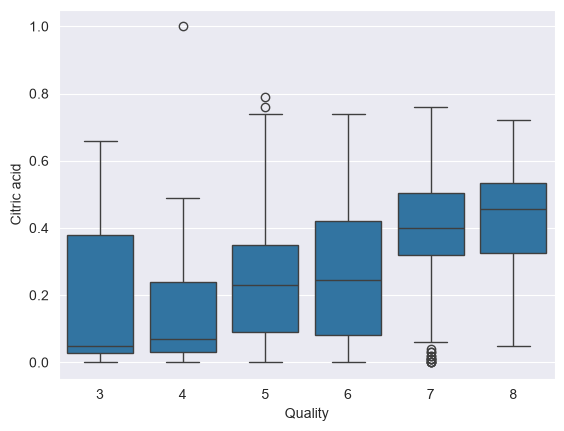

In [23]:
sns.boxplot(data=df, x="quality", y="citric acid")
plt.xlabel("Quality")
plt.ylabel("Citric acid")
plt.show()

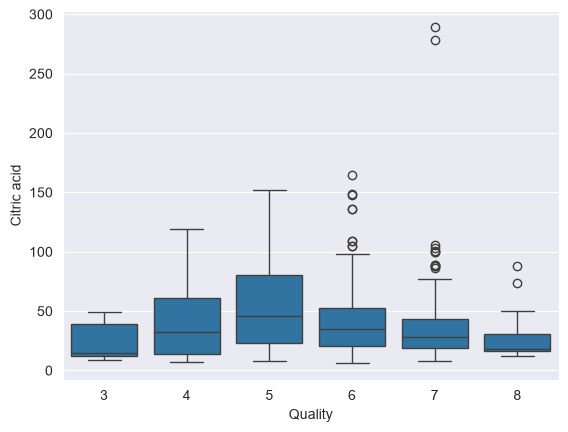

In [24]:
sns.boxplot(data=df, x="quality", y="total sulfur dioxide")
plt.xlabel("Quality")
plt.ylabel("Citric acid")
plt.show()

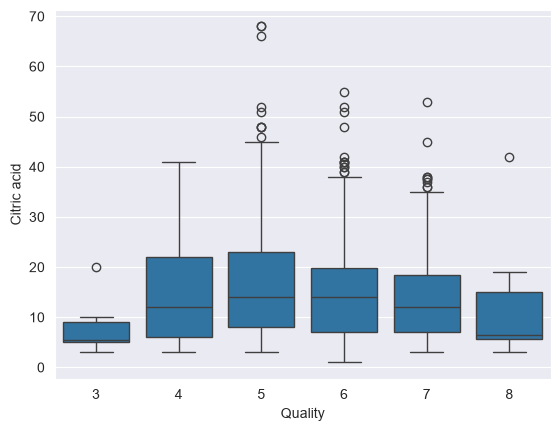

In [25]:
sns.boxplot(data=df, x="quality", y="free sulfur dioxide")
plt.xlabel("Quality")
plt.ylabel("Citric acid")
plt.show()

In [26]:
print(df_grouped.describe())

        fixed acidity                                                     \
                count      mean       std  min   25%   50%     75%   max   
quality                                                                    
3                 6.0  8.450000  2.032486  6.7  7.15  7.45   9.700  11.6   
4                33.0  7.809091  1.685668  4.6  6.70  7.60   8.500  12.5   
5               483.0  8.161077  1.557746  5.0  7.10  7.80   8.900  15.9   
6               462.0  8.317749  1.771585  5.0  7.00  7.90   9.275  14.3   
7               143.0  8.851049  2.105187  4.9  7.40  8.70  10.100  15.6   
8                16.0  8.806250  2.089168  5.0  7.35  8.85  10.400  12.6   

        volatile acidity            ...  alcohol           Id               \
                   count      mean  ...      75%   max  count         mean   
quality                             ...                                      
3                    6.0  0.897500  ...  10.1375  10.9    6.0  1121.166667   
4  

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [30]:
print(df_grouped["volatile acidity"].describe())

         count      mean       std   min     25%     50%      75%   max
quality                                                                
3          6.0  0.897500  0.367556  0.58  0.6475  0.8175  0.95375  1.58
4         33.0  0.700000  0.216373  0.35  0.5200  0.6750  0.88000  1.09
5        483.0  0.585280  0.168226  0.18  0.4600  0.5900  0.68000  1.33
6        462.0  0.504957  0.159649  0.16  0.3900  0.5000  0.60875  1.04
7        143.0  0.393671  0.133795  0.12  0.3000  0.3600  0.48000  0.84
8         16.0  0.410000  0.147919  0.26  0.3275  0.3550  0.42000  0.85


## 2. Feature Analysis: Volatile Acidity
Let's analyze how 'volatile acidity' behaves across different quality classes.

**Observation:** There is a significant and clear decrease in volatile acidity as wine quality increases. Lower volatile acidity is generally associated with better-tasting wines.

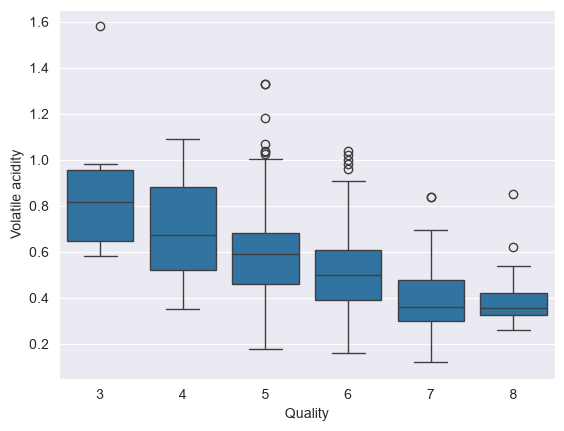

In [32]:
sns.boxplot(data=df, x="quality", y="volatile acidity")
plt.xlabel("Quality")
plt.ylabel("Volatile acidity")
plt.show()

**Boxplot Analysis for Volatile Acidity:**
Although higher quality wines generally have lower volatile acidity, the boxplot reveals an interesting pattern: some top-tier wines (quality 8) have outliers reaching the high volatile acidity levels typically found in the lowest quality wines (quality 3). This indicates that while volatile acidity is a strong indicator, it is not the *only* factor determining a score of 8.

In [35]:
print(df_grouped["chlorides"].describe())

         count      mean       std    min      25%     50%      75%    max
quality                                                                   
3          6.0  0.105333  0.053298  0.061  0.07500  0.0800  0.12325  0.200
4         33.0  0.094788  0.094873  0.045  0.06700  0.0780  0.08800  0.610
5        483.0  0.091770  0.052325  0.039  0.07400  0.0810  0.09400  0.611
6        462.0  0.085281  0.040465  0.034  0.06900  0.0785  0.08800  0.415
7        143.0  0.075217  0.030519  0.012  0.06200  0.0730  0.08500  0.358
8         16.0  0.070187  0.010521  0.045  0.06625  0.0715  0.07650  0.086


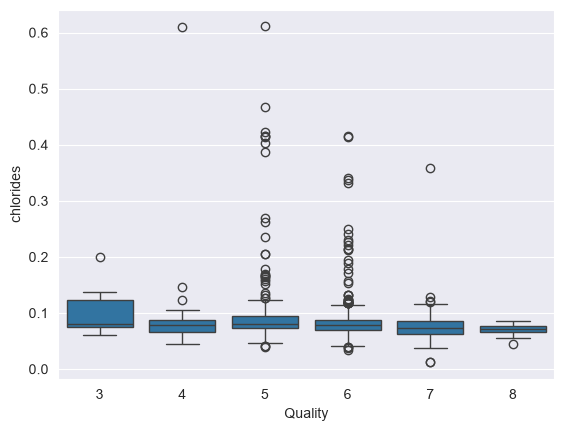

In [36]:
sns.boxplot(data=df, x="quality", y="chlorides")
plt.xlabel("Quality")
plt.ylabel("chlorides")
plt.show()

# özellikle orta iki kalite düzeyinde ciddi outlierlar var

## 3. Feature Analysis: Chlorides
**Observation:** A negative correlation is observed here. As chloride concentration decreases, the wine quality tends to increase.

**Boxplot Analysis for Chlorides:**
The distribution shows a massive presence of outliers, particularly within the average quality levels (classes 5 and 6). Premium wines (classes 7 and 8) have a much tighter distribution with fewer extreme chloride values.

In [37]:
print(df_grouped["free sulfur dioxide"].describe())

         count       mean        std  min   25%   50%    75%   max
quality                                                           
3          6.0   8.166667   6.242329  3.0  5.00   5.5   9.00  20.0
4         33.0  14.848485  10.198410  3.0  6.00  12.0  22.00  41.0
5        483.0  16.612836  10.960945  3.0  8.00  14.0  23.00  68.0
6        462.0  15.215368   9.526174  1.0  7.00  14.0  19.75  55.0
7        143.0  14.538462   9.904842  3.0  7.00  12.0  18.50  53.0
8         16.0  11.062500   9.629598  3.0  5.75   6.5  15.00  42.0


In [38]:
print(df_grouped["total sulfur dioxide"].describe())

         count       mean        std   min   25%   50%    75%    max
quality                                                             
3          6.0  24.500000  18.360283   9.0  12.5  15.0  39.25   49.0
4         33.0  40.606061  28.487870   7.0  14.0  32.0  61.00  119.0
5        483.0  55.299172  36.548411   8.0  23.5  46.0  80.50  152.0
6        462.0  39.941558  24.605231   6.0  21.0  35.0  53.00  165.0
7        143.0  37.489510  36.743279   8.0  19.0  28.0  43.00  289.0
8         16.0  29.375000  22.700587  12.0  16.0  18.0  31.00   88.0


In [40]:
print(df_grouped["density"].describe())

         count      mean       std      min       25%       50%       75%  \
quality                                                                     
3          6.0  0.997682  0.002218  0.99476  0.996263  0.997565  0.999070   
4         33.0  0.996669  0.001734  0.99340  0.995650  0.996640  0.997600   
5        483.0  0.997073  0.001637  0.99256  0.996100  0.996920  0.997950   
6        462.0  0.996610  0.002002  0.99007  0.995385  0.996520  0.997868   
7        143.0  0.996071  0.002292  0.99064  0.994690  0.995680  0.997355   
8         16.0  0.995553  0.002217  0.99170  0.994430  0.995580  0.997225   

             max  
quality           
3        1.00080  
4        1.00100  
5        1.00315  
6        1.00369  
7        1.00320  
8        0.99880  


In [41]:
print(df_grouped["pH"].describe())

         count      mean       std   min    25%    50%     75%   max
quality                                                             
3          6.0  3.361667  0.149588  3.16  3.265  3.355  3.4750  3.55
4         33.0  3.391212  0.210650  2.74  3.300  3.380  3.5100  3.90
5        483.0  3.302091  0.149590  2.88  3.200  3.300  3.3900  3.74
6        462.0  3.323788  0.157118  2.86  3.220  3.320  3.4200  4.01
7        143.0  3.287133  0.151214  2.92  3.200  3.270  3.3800  3.78
8         16.0  3.240625  0.196925  2.88  3.150  3.225  3.2675  3.72


In [42]:
print(df_grouped["sulphates"].describe())

# şarap kalitesi arttıkça sülfattada artış var.

         count      mean       std   min     25%   50%    75%   max
quality                                                            
3          6.0  0.550000  0.085557  0.40  0.5275  0.56  0.615  0.63
4         33.0  0.637879  0.292476  0.33  0.5200  0.56  0.620  2.00
5        483.0  0.613375  0.160980  0.39  0.5200  0.58  0.640  1.62
6        462.0  0.676537  0.163353  0.40  0.5800  0.64  0.740  1.95
7        143.0  0.743566  0.143681  0.39  0.6550  0.74  0.840  1.36
8         16.0  0.766250  0.121867  0.63  0.6900  0.73  0.820  1.10


## 4. Feature Analysis: Sulphates
**Observation:** In contrast to volatile acidity and chlorides, there is a positive trend between sulphate concentration and wine quality. Higher quality wines tend to have higher sulphate levels.

### 📌 Intermediate Summary
Based on the distributions and grouped averages, we can establish the following general rules as wine quality increases:
* **Sulphates:** Tend to increase.
* **Chlorides:** Tend to decrease.
* **Volatile Acidity:** Shows a significant decrease.

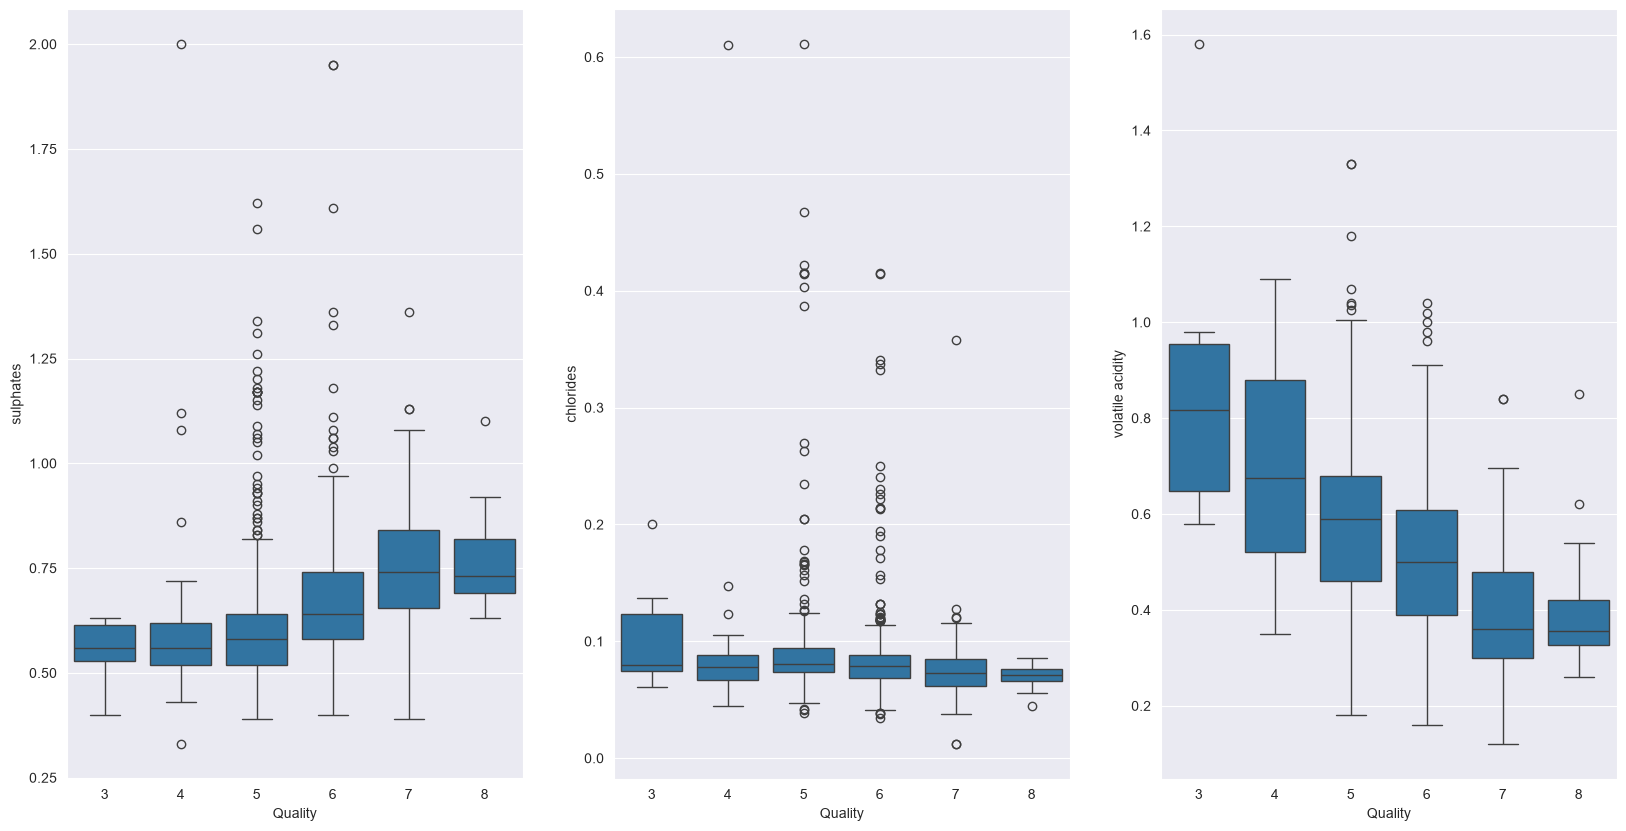

In [46]:
plt.figure(figsize=(20,10))

plt.subplot(1,3,1)
sns.boxplot(data=df, x="quality", y="sulphates")
plt.xlabel("Quality")
plt.ylabel("sulphates")

plt.subplot(1,3,2)
sns.boxplot(data=df, x="quality", y="chlorides")
plt.xlabel("Quality")
plt.ylabel("chlorides")

plt.subplot(1,3,3)
sns.boxplot(data=df, x="quality", y="volatile acidity")
plt.xlabel("Quality")
plt.ylabel("volatile acidity")
plt.show()

## 5. Deep Dive: What makes a wine "Premium"?
Since the chemical differences between class 7 and class 8 wines are subtle (for instance, their volatile acidity averages are almost identical), we need to isolate these high-quality wines to see what truly sets a top-tier (8) wine apart from a very good (7) wine.

Let's filter the dataset for qualities 7 and 8, and examine the sulfur dioxide distributions.

In [69]:
print(df_grouped["chlorides"].describe().loc[[7,8]])

         count      mean       std    min      25%     50%     75%    max
quality                                                                  
7        143.0  0.075217  0.030519  0.012  0.06200  0.0730  0.0850  0.358
8         16.0  0.070187  0.010521  0.045  0.06625  0.0715  0.0765  0.086


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [73]:
print(df_grouped["free sulfur dioxide"].describe().loc[[7,8]])

         count       mean       std  min   25%   50%   75%   max
quality                                                         
7        143.0  14.538462  9.904842  3.0  7.00  12.0  18.5  53.0
8         16.0  11.062500  9.629598  3.0  5.75   6.5  15.0  42.0


In [74]:
print(df_grouped["total sulfur dioxide"].describe().loc[[7,8]])

         count      mean        std   min   25%   50%   75%    max
quality                                                           
7        143.0  37.48951  36.743279   8.0  19.0  28.0  43.0  289.0
8         16.0  29.37500  22.700587  12.0  16.0  18.0  31.0   88.0


Text(0, 0.5, 'total sulfur dioxide')

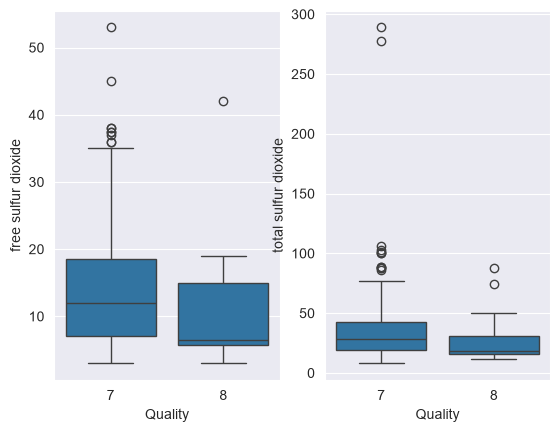

In [78]:

high_quality = df[df["quality"].isin([7, 8])]

plt.subplot(1, 2, 1)
sns.boxplot(data=high_quality, x="quality", y="free sulfur dioxide")
plt.xlabel("Quality")
plt.ylabel("free sulfur dioxide")

plt.subplot(1, 2, 2)
sns.boxplot(data=high_quality, x="quality", y="total sulfur dioxide")
plt.xlabel("Quality")
plt.ylabel("total sulfur dioxide")

In [79]:
print(df_grouped["total sulfur dioxide"].describe())

         count       mean        std   min   25%   50%    75%    max
quality                                                             
3          6.0  24.500000  18.360283   9.0  12.5  15.0  39.25   49.0
4         33.0  40.606061  28.487870   7.0  14.0  32.0  61.00  119.0
5        483.0  55.299172  36.548411   8.0  23.5  46.0  80.50  152.0
6        462.0  39.941558  24.605231   6.0  21.0  35.0  53.00  165.0
7        143.0  37.489510  36.743279   8.0  19.0  28.0  43.00  289.0
8         16.0  29.375000  22.700587  12.0  16.0  18.0  31.00   88.0


In [80]:
print(df_grouped["free sulfur dioxide"].describe())

         count       mean        std  min   25%   50%    75%   max
quality                                                           
3          6.0   8.166667   6.242329  3.0  5.00   5.5   9.00  20.0
4         33.0  14.848485  10.198410  3.0  6.00  12.0  22.00  41.0
5        483.0  16.612836  10.960945  3.0  8.00  14.0  23.00  68.0
6        462.0  15.215368   9.526174  1.0  7.00  14.0  19.75  55.0
7        143.0  14.538462   9.904842  3.0  7.00  12.0  18.50  53.0
8         16.0  11.062500   9.629598  3.0  5.75   6.5  15.00  42.0


## 🏁 Final Conclusion
Based on this Exploratory Data Analysis, we can draw the following conclusions:

1. **Primary Indicator:** **`Volatile acidity`** appears to be the primary driving factor in determining the general quality of a wine. Keeping this value low is essential for achieving an above-average score.
2. **The Premium Differentiator:** When distinguishing between premium wines (quality classes 7 vs. 8), general indicators like volatile acidity plateau. Among these top-tier wines, the quality difference is largely determined by **`free sulfur dioxide`** and **`total sulfur dioxide`** levels. Lower sulfur dioxide concentrations are heavily favored in class 8 wines compared to class 7.

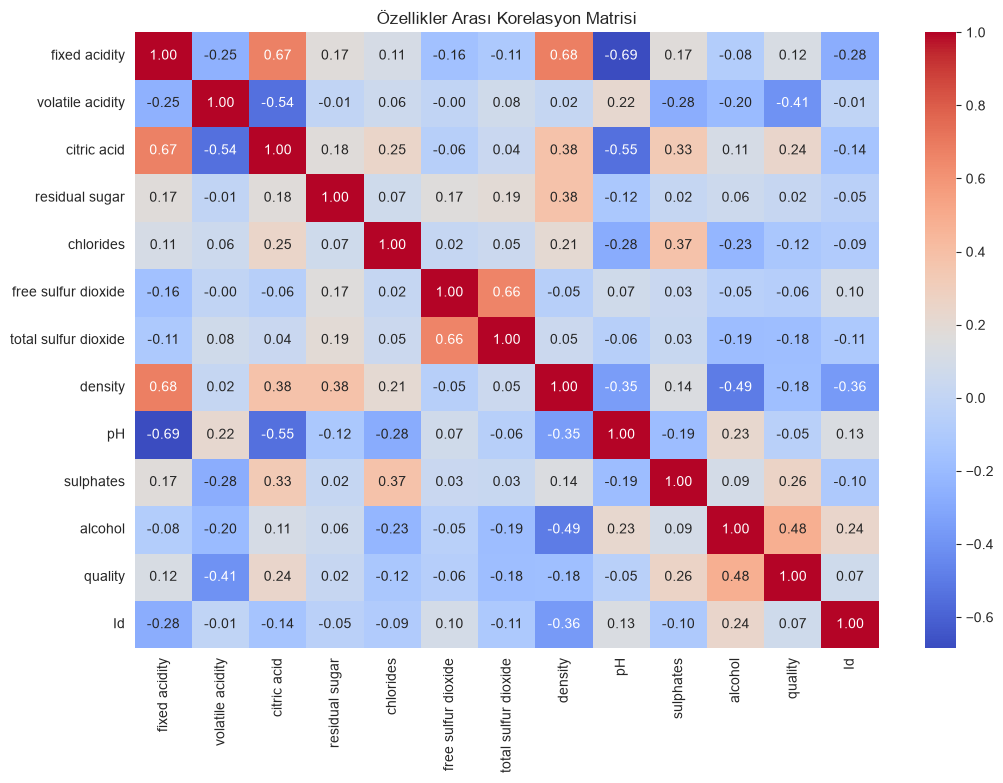

In [81]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Özellikler Arası Korelasyon Matrisi")
plt.show()